**Objective:**
To predict the employee's Performance Score using Age, Years of Experience, Monthly Salary, Working Hours Per Day, Projects Handled, and Job Satisfaction.


**Interpretation:**
Linear Regression identifies the relationship between employee attributes and Performance Score. The model predicts Performance Score and evaluates accuracy using RMSE and R² Score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

# step 1 : upload the file
uploaded = files.upload()

df = pd.read_csv("ML-CaseStudy2-Dataset.csv")
df.head()

Saving ML-CaseStudy2-Dataset.csv to ML-CaseStudy2-Dataset.csv


,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,11de2b9e-2148-4a1e-951b-1323d8f5f941,Austin Rodriguez,59.0,36,25860.0,11,13,6.37,sales,Pune,26.50,1
1,816703b6-7f5c-4511-8bf3-ace06d28333c,Stephanie Salazar,31.0,4,69131.0,11,8,6.86,IT,Mumbai,43.23,1
2,d10e1435-380e-4727-bab0-d1db39ea5e9e,Mrs. Jaclyn Chavez,22.0,0,87955.0,9,2,2.64,Human Resource,Mumbai,43.28,1
3,d8456859-9280-4bb0-a772-78952813e838,Susan Quinn,42.0,14,131970.0,13,12,9.76,sales,Chennai,77.60,1
4,791f7234-a526-4b85-adaa-70b4b01cbad8,Matthew Nelson,35.0,13,92435.0,10,4,6.33,sales,Hyderabad,58.22,0


In [3]:
df.shape

(5050, 12)

In [4]:
df.columns

Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')

In [5]:
df.dtypes

,0
Employee_ID,object
Employee_Name,object
Age,float64
Years_of_Experience,int64
Monthly_Salary,float64
Working_Hours_Per_Day,int64
Projects_Handled,int64
Job_Satisfaction,float64
Department,object
City,object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            5050 non-null   object 
 1   Employee_Name          5050 non-null   object 
 2   Age                    4950 non-null   float64
 3   Years_of_Experience    5050 non-null   int64  
 4   Monthly_Salary         4949 non-null   float64
 5   Working_Hours_Per_Day  5050 non-null   int64  
 6   Projects_Handled       5050 non-null   int64  
 7   Job_Satisfaction       4949 non-null   float64
 8   Department             5050 non-null   object 
 9   City                   5050 non-null   object 
 10  Performance_Score      5050 non-null   float64
 11  Attrition_Flag         5050 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 473.6+ KB


In [35]:
print(df.describe())

               Age  Years_of_Experience  Monthly_Salary  \
count  4950.000000          5050.000000    4.949000e+03   
mean     40.005253            15.730693    9.148913e+04   
std      11.246498            11.153742    6.667466e+04   
min      21.000000             0.000000    2.500500e+04   
25%      30.000000             6.000000    5.686000e+04   
50%      40.000000            15.000000    8.996500e+04   
75%      50.000000            25.000000    1.203690e+05   
max      59.000000            39.000000    1.484850e+06   

       Working_Hours_Per_Day  Projects_Handled  Job_Satisfaction  \
count            5050.000000       5050.000000       4949.000000   
mean                8.531881          7.500198          5.585625   
std                 2.885185          4.069959          2.587281   
min                 4.000000          1.000000          1.000000   
25%                 6.000000          4.000000          3.380000   
50%                 8.000000          7.000000          5.65

In [36]:
# Check null values
print(df.isnull().sum())

Employee_ID                0
Employee_Name              0
Age                      100
Years_of_Experience        0
Monthly_Salary           101
Working_Hours_Per_Day      0
Projects_Handled           0
Job_Satisfaction         101
Department                 0
City                       0
Performance_Score          0
Attrition_Flag             0
dtype: int64


In [37]:
df.duplicated().any()

np.True_

In [38]:
df.duplicated().sum()

np.int64(46)

In [39]:
df[df.duplicated()]

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
5000,8db8a8a9-44b3-4885-84b2-9c1e88f4aa5a,Scott Schwartz,48.0,19,57009.0,7,7,2.93,Finance,Mumbai,34.21,1
5001,936d5774-9919-4056-b248-2c4c58d4f683,Shelby Garcia,37.0,10,45543.0,13,12,6.03,marketing,Mumbai,25.11,1
5002,89f60d5a-db33-47ce-8157-427ad3e2937c,Ann Griffin,21.0,0,140749.0,9,13,2.24,marketing,Chennai,65.38,1
5003,1c64a810-2b94-4ef5-96ba-e13f53e9368f,Keith Padilla,45.0,22,148721.0,13,8,9.54,marketing,Hyderabad,104.63,1
5004,5bb73a9d-a788-4bb9-80ba-9b9987b1c09e,Cody Thompson,46.0,18,138985.0,11,9,5.19,Human Resource,Delhi,86.73,1
5005,16529f4a-023f-479a-b1ef-37f0aa0a1a00,Alicia Simpson,55.0,32,25302.0,11,6,3.13,marketing,Mumbai,25.71,1
5006,dcd1323d-a7e7-4153-bd69-3b63b73d7607,Jamie Burns,31.0,7,95130.0,9,11,1.12,Marketing,Pune,48.32,1
5007,5dd58345-0725-4df5-b2cf-d0a41c702383,Amber Avila,34.0,12,130327.0,13,1,1.04,marketing,Mumbai,77.17,1
5008,186aa530-9807-42a8-aff0-7d8a54601d75,Jacqueline Brooks,43.0,23,116411.0,12,10,1.31,Marketing,Mumbai,71.21,1
5009,44567183-d116-43ae-9131-d5a8ad7032bb,Jody Green,48.0,22,134743.0,6,10,8.18,Marketing,Pune,86.93,0


In [41]:
data1 = df.drop_duplicates()

In [42]:
print(df.isnull().sum())

Employee_ID                0
Employee_Name              0
Age                      100
Years_of_Experience        0
Monthly_Salary           101
Working_Hours_Per_Day      0
Projects_Handled           0
Job_Satisfaction         101
Department                 0
City                       0
Performance_Score          0
Attrition_Flag             0
dtype: int64


In [43]:
df.duplicated().any()

np.True_

In [44]:
data1.shape

(5004, 12)

In [46]:
#Indexing columns
df = data1.isnull().sum().reset_index()
#Rename column
df.columns = ['column', 'null_records']
#Create new colums and Find out null value percentage
df['% null records'] = (df['null_records']/5004)*100
df

,column,null_records,% null records
0,Employee_ID,0,0.000000
1,Employee_Name,0,0.000000
2,Age,100,1.998401
3,Years_of_Experience,0,0.000000
4,Monthly_Salary,100,1.998401
5,Working_Hours_Per_Day,0,0.000000
6,Projects_Handled,0,0.000000
7,Job_Satisfaction,100,1.998401
8,Department,0,0.000000
9,City,0,0.000000


In [47]:
data1.columns.str.strip()

Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')

In [48]:
Numerical_columns = data1.select_dtypes(include="number").columns.to_list()
print(Numerical_columns)


['Age', 'Years_of_Experience', 'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled', 'Job_Satisfaction', 'Performance_Score', 'Attrition_Flag']


In [50]:
Categorical_columns = data1.select_dtypes(exclude="number").columns.to_list()
print(Categorical_columns)

['Employee_ID', 'Employee_Name', 'Department', 'City']


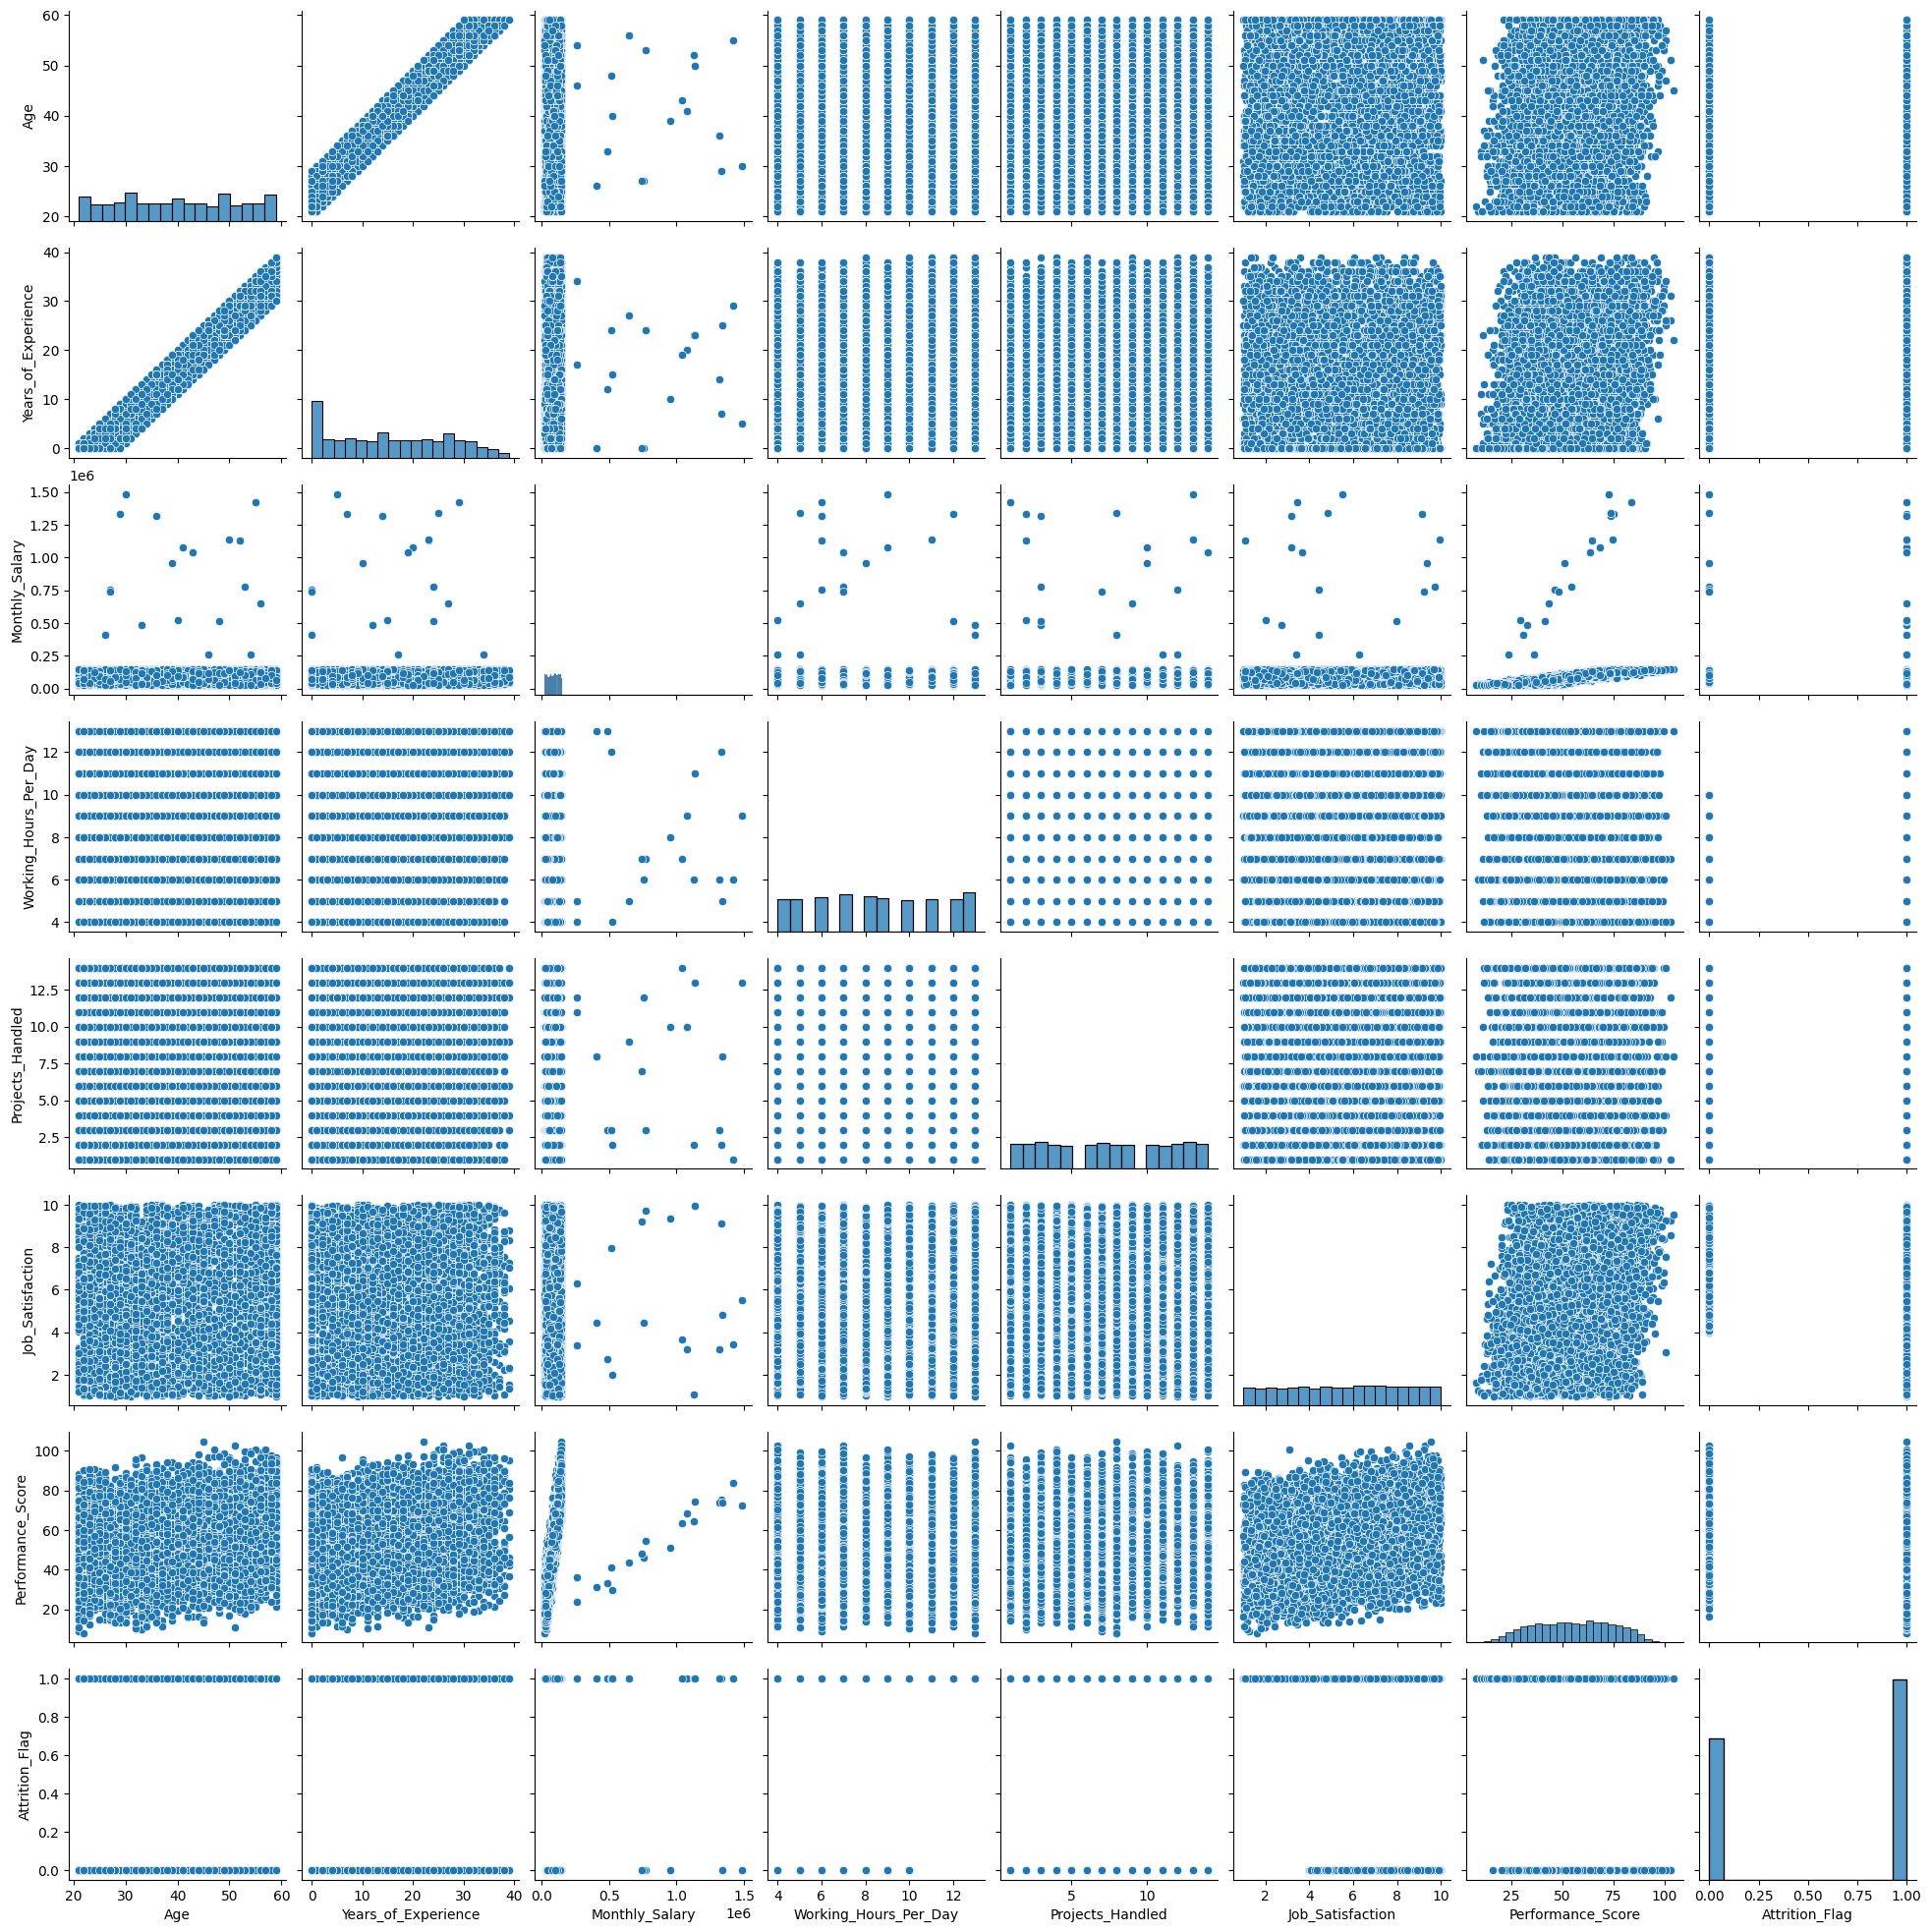

In [51]:
# Pair plot
sns.pairplot(data1)
plt.show()

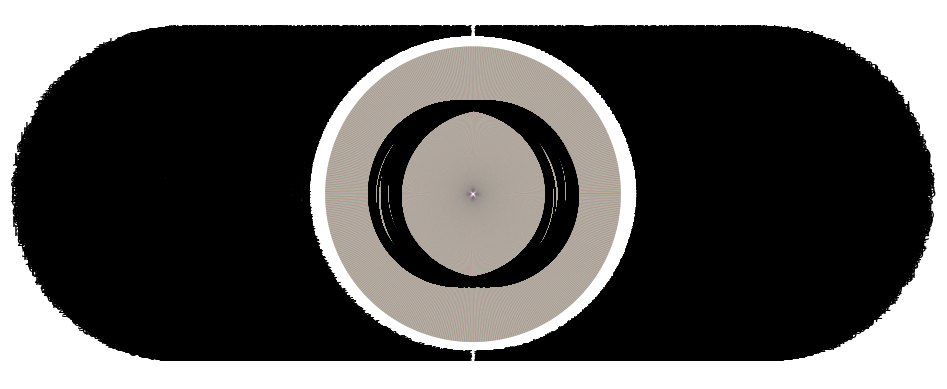

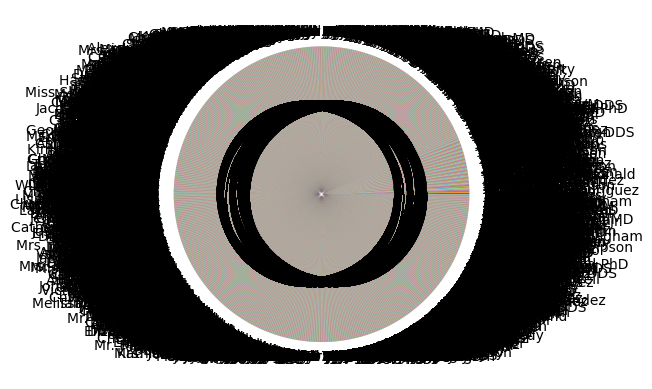

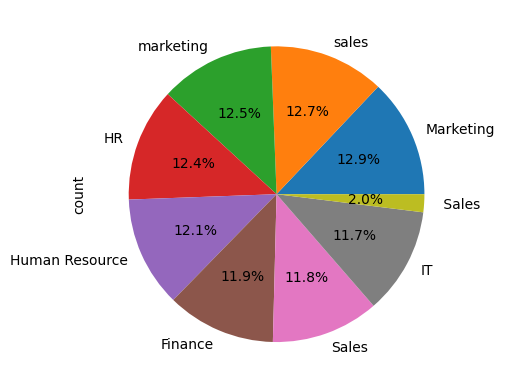

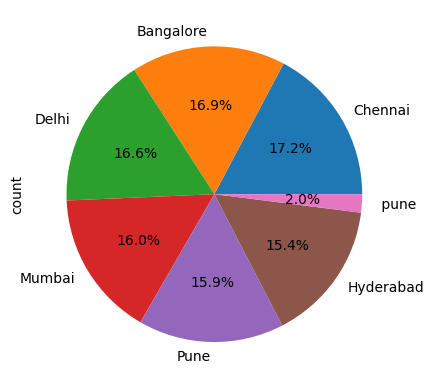

In [52]:
# Pie Plot
for col in Categorical_columns:
  data1[col].value_counts().plot(kind = 'pie', autopct= '%1.1f%%')
  plt.show()

In [56]:
print(data1.columns)

Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')


In [58]:
corr_data = data1[['Age', 'Years_of_Experience', 'Monthly_Salary']].corr()
corr_data

,Age,Years_of_Experience,Monthly_Salary
Age,1.000000,0.968839,-0.000703
Years_of_Experience,0.968839,1.000000,-0.003089
Monthly_Salary,-0.000703,-0.003089,1.000000


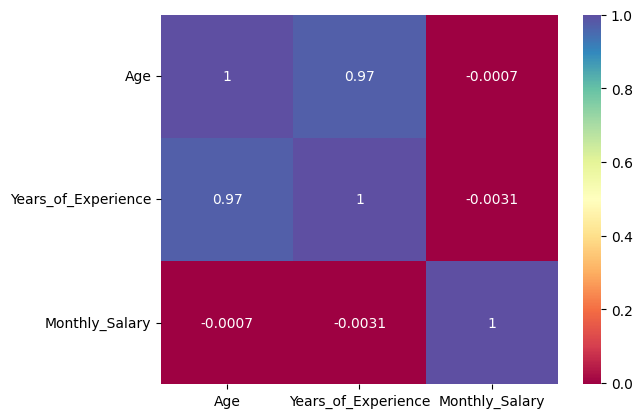

In [59]:
sns.heatmap(corr_data, annot=True, cmap='Spectral')
plt.show()

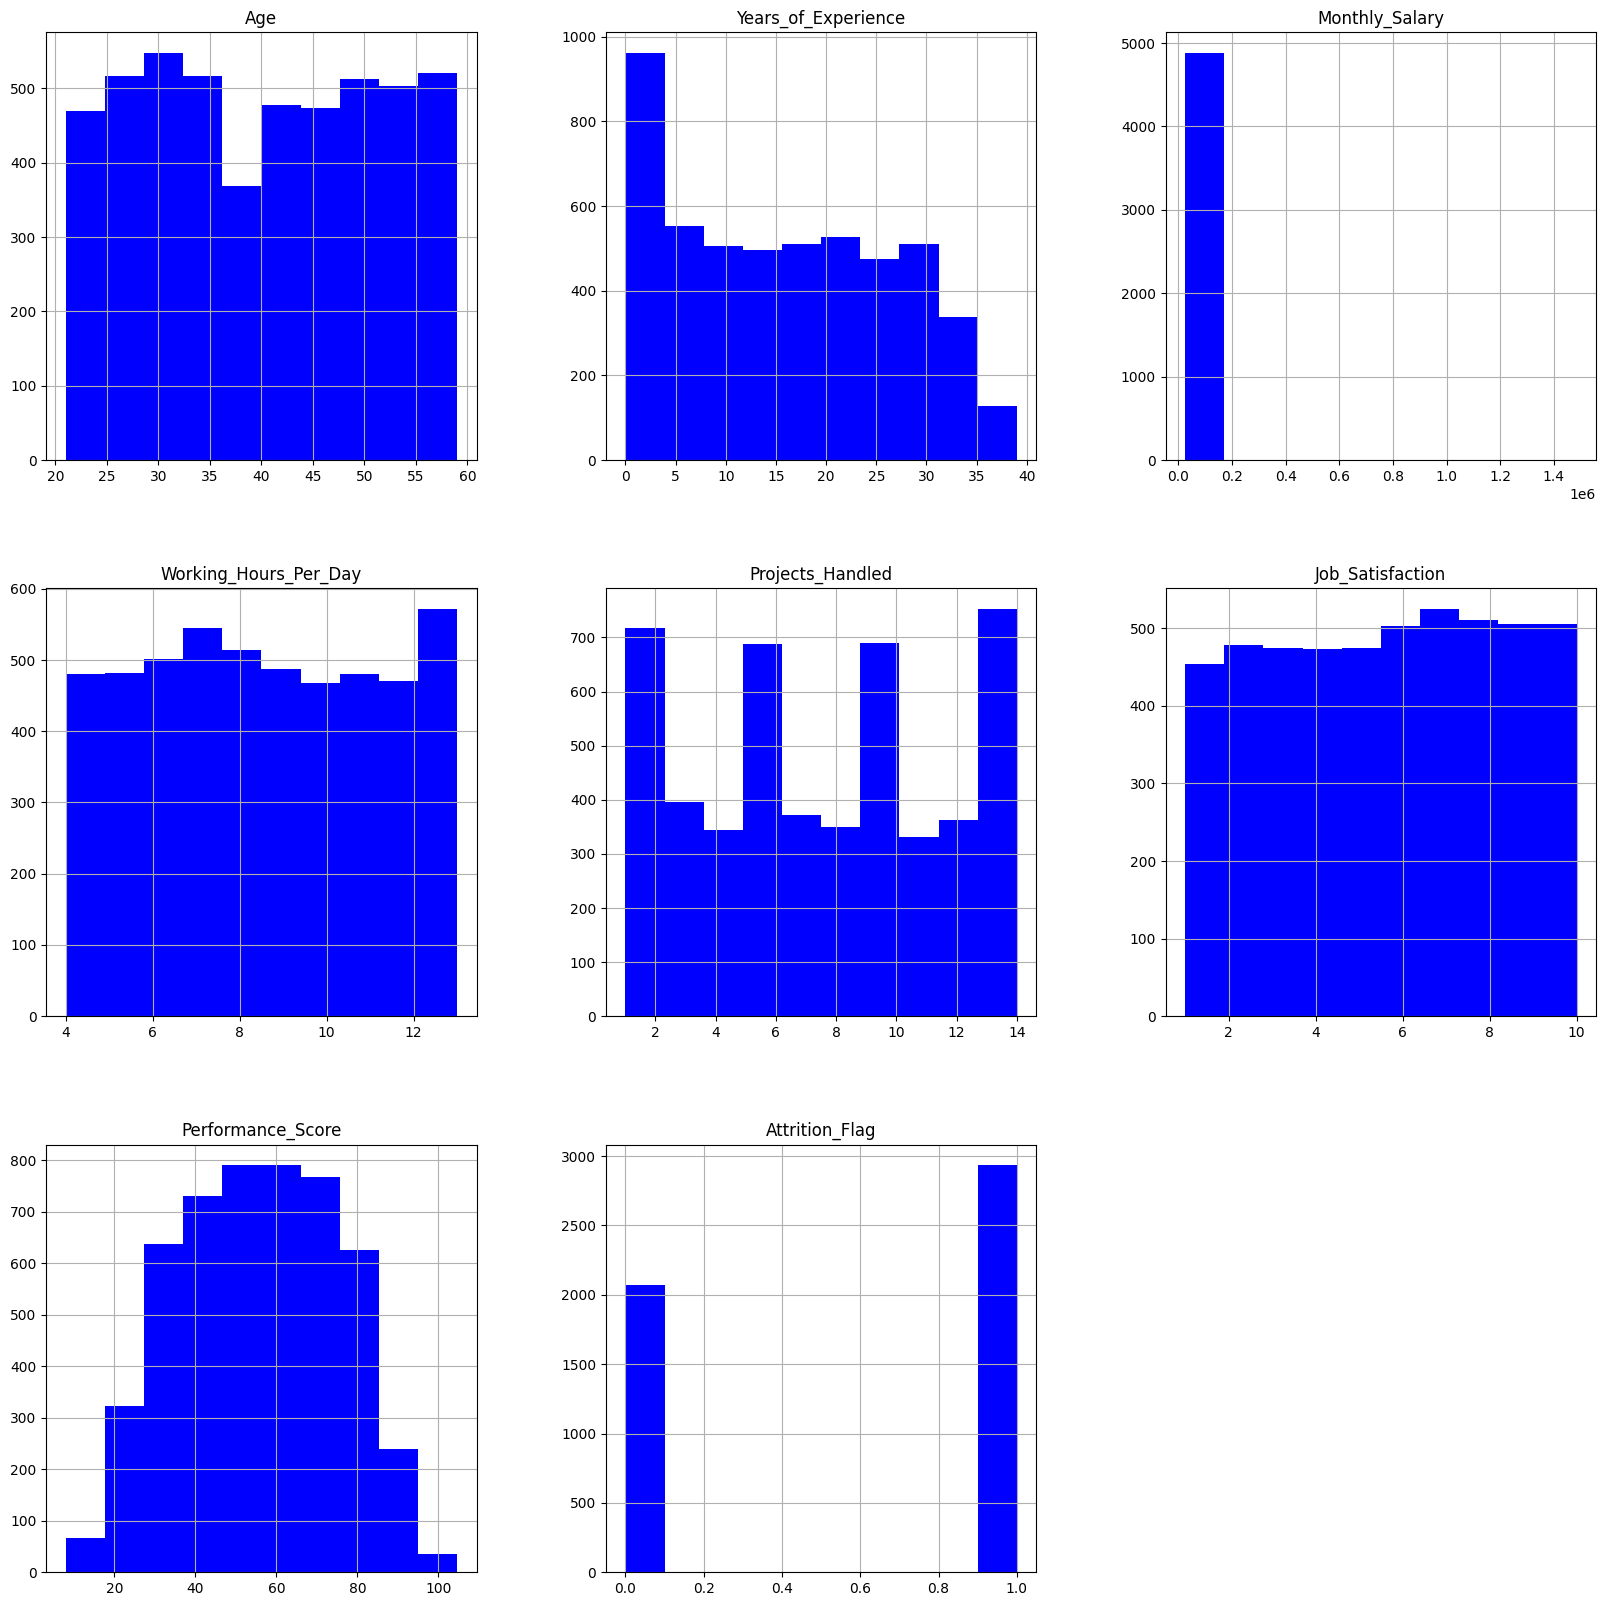

In [60]:
# Histogram
data1.hist(figsize=(20,20),color='blue')
plt.show()

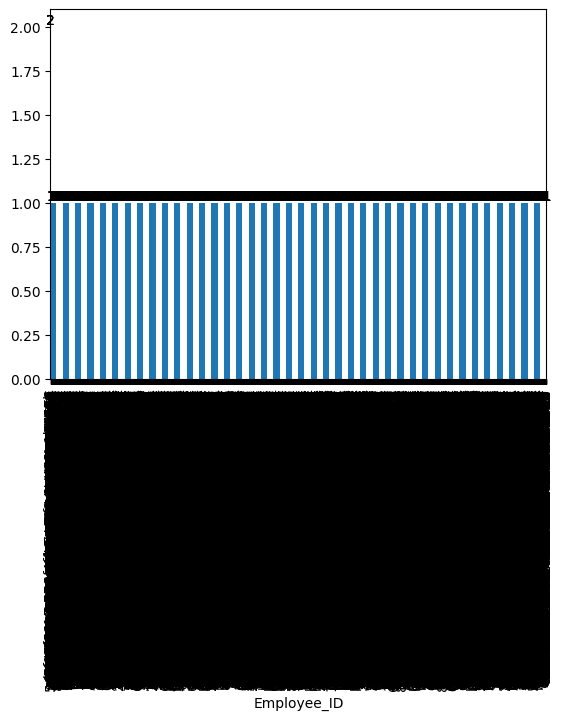

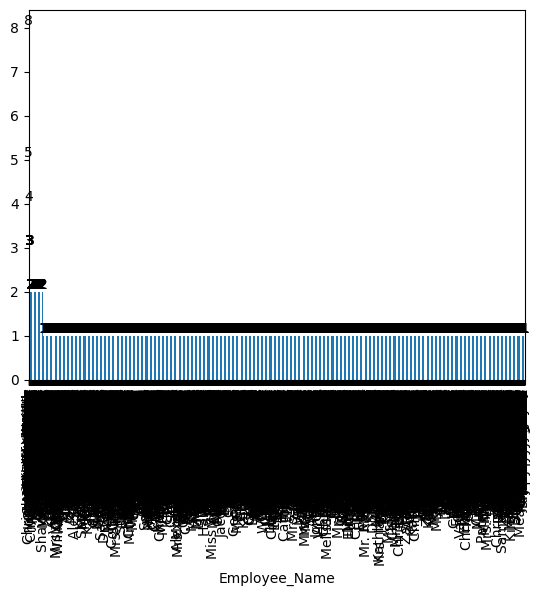

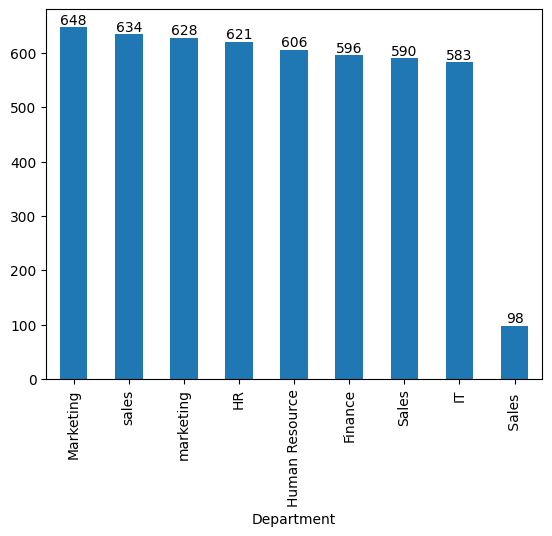

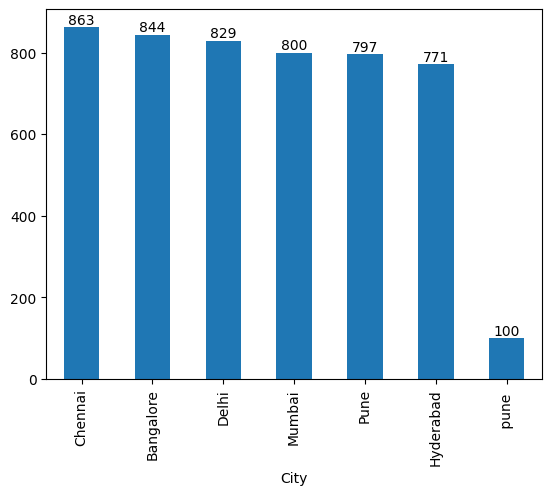

In [61]:
# Bar Chart

for col in Categorical_columns:
  ax = data1[col].value_counts().plot(kind = 'bar')
  for i in ax.containers:
    ax.bar_label(i)
    plt.show()

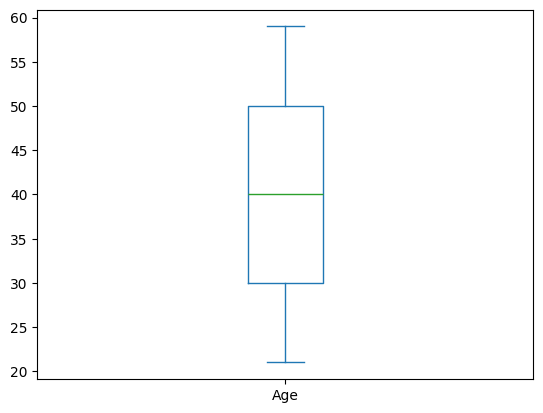

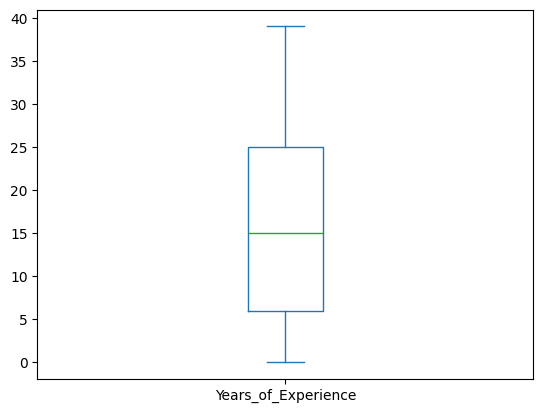

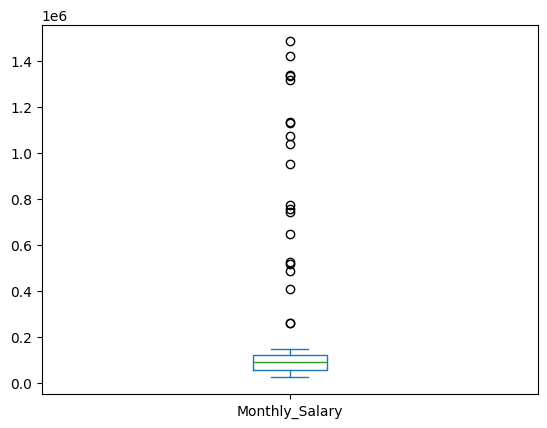

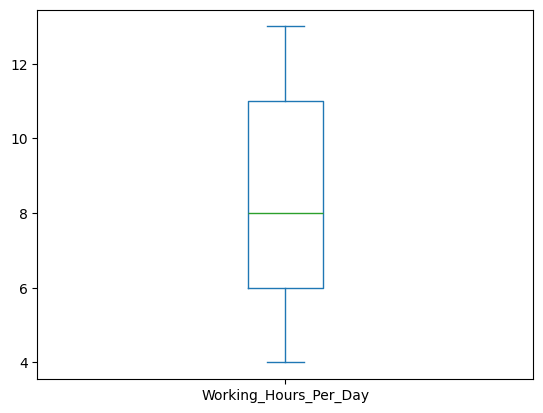

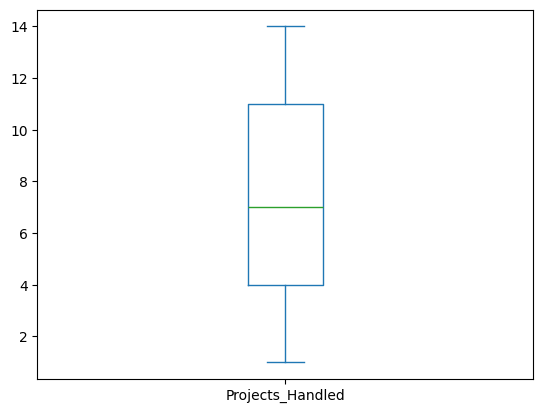

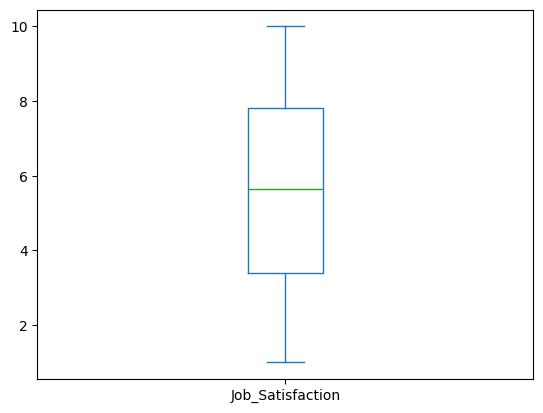

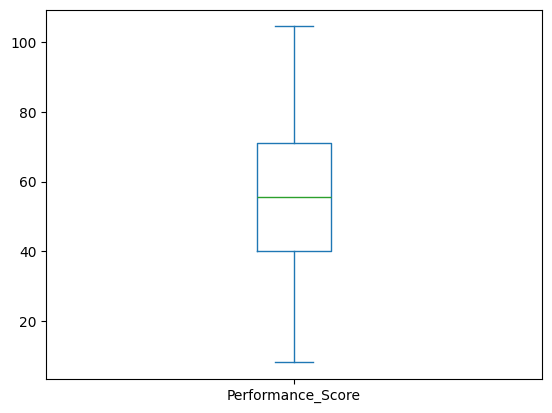

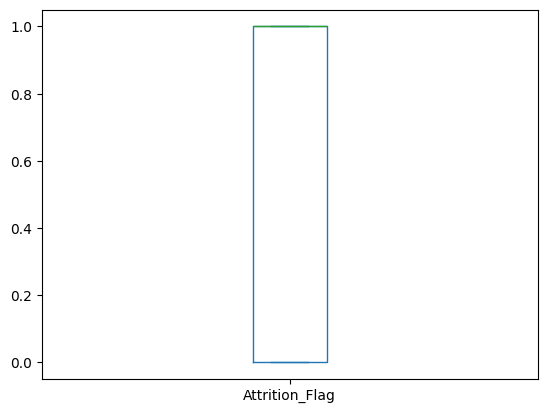

In [62]:
# Box plot

for col in Numerical_columns:
  data1[col].plot(kind='box')
  plt.show()

In [ ]:
# label encoding : where need to convert categorical data into numerical

In [63]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [64]:
data1['Monthly_Salary'] = le.fit_transform(data1['Monthly_Salary'])
data1['Working_Hours_Per_Day'] = le.fit_transform(data1['Working_Hours_Per_Day'])
data1['Projects_Handled'] = le.fit_transform(data1['Projects_Handled'])
data1['Job_Satisfaction'] = le.fit_transform(data1['Job_Satisfaction'])
data1['Performance_Score'] = le.fit_transform(data1['Performance_Score'])
data1['Attrition_Flag'] = le.fit_transform(data1['Attrition_Flag'])
data1['Working_Hours_Per_Day'] = le.fit_transform(data1['Working_Hours_Per_Day'])
data1['Projects_Handled'] = le.fit_transform(data1['Projects_Handled'])

In [65]:
data1

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,11de2b9e-2148-4a1e-951b-1323d8f5f941,Austin Rodriguez,59.0,36,30,7,12,533,sales,Pune,288,1
1,816703b6-7f5c-4511-8bf3-ace06d28333c,Stephanie Salazar,31.0,4,1643,7,7,582,IT,Mumbai,1143,1
2,d10e1435-380e-4727-bab0-d1db39ea5e9e,Mrs. Jaclyn Chavez,22.0,0,2351,5,1,162,Human Resource,Mumbai,1144,1
3,d8456859-9280-4bb0-a772-78952813e838,Susan Quinn,42.0,14,4081,9,11,870,sales,Chennai,3023,1
4,791f7234-a526-4b85-adaa-70b4b01cbad8,Matthew Nelson,35.0,13,2524,6,3,529,sales,Hyderabad,1977,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4999,eec9b3d8-b67a-429f-8017-8d888af2fb1e,Chad Tran,48.0,20,90,4,0,447,Finance,Delhi,371,1
5029,5c684b02-3c6a-4c0e-a0c9-577a721af9dc,Michael Jackson,33.0,4,325,3,13,573,Sales,Chennai,134,1
5042,4cf67575-bda8-47da-9ddc-64550ba6bd25,Brian Pham,46.0,24,3623,2,3,577,sales,Mumbai,2804,0
5045,d5ee84ca-a770-4f16-a522-0ea23a10125b,Alvin Griffin,57.0,35,2042,2,6,836,HR,Delhi,1924,0


In [66]:
# Step 1 Import Lab
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Objective:

The objective of this experiment is to implement
Linear Regression algorithm to predict the
target variable based on independent variables
such as Age, Years of Experience, and Monthly Salary.

Linear Regression is a supervised machine learning
algorithm that establishes a linear relationship
between input (independent) variables and
output (dependent/target) variable.

The aim is to train the model on the given dataset,
evaluate its performance using R2 Score and MSE,
and understand how well the model predicts
the target values.

In [69]:
# Define Featrue (x) and target (y) Set 2
# Define Features (X)
X = data1[['Age',
           'Years_of_Experience',
           'Monthly_Salary',
           'Working_Hours_Per_Day',
           'Projects_Handled',
           'Job_Satisfaction',
           'Performance_Score',
           'Attrition_Flag']]

# Define Target (y)
y = data1['Attrition_Flag']

In [70]:
# Step 3
X_train ,X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

print("\nTraning set Size:", X_train.shape)
print("\nTesting Set Size:", X_test.shape)


Traning set Size: (4003, 8)

Testing Set Size: (1001, 8)


In [71]:
# Step 4 : split Data
X_train ,X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

print("\nTraning set Size:", X_train.shape)
print("\nTesting Set Size:", X_test.shape)


Traning set Size: (4003, 8)

Testing Set Size: (1001, 8)


In [74]:
data1 = data1.dropna()

In [78]:
data1 = data1.fillna(data1.mean(numeric_only=True))

In [79]:
# Step 4 : split Data
X_train ,X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

In [82]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


In [83]:
coeff_df = pd.DataFrame(model.coef_, X.columns,columns=["Coefficient"])
print("\nModel Coefficients:")
print(coeff_df)
print("Intercept:",model.intercept_)


Model Coefficients:
                        Coefficient
Age                    1.017478e-17
Years_of_Experience   -1.240395e-17
Monthly_Salary         8.051048e-19
Working_Hours_Per_Day -1.700889e-16
Projects_Handled       1.474880e-17
Job_Satisfaction       4.095087e-18
Performance_Score     -1.131636e-18
Attrition_Flag         1.000000e+00
Intercept: -1.4432899320127035e-15


In [84]:
y_pred = model.predict(X_test)

In [85]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.3f}")


Model Performance:
Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
R2 Score: 1.000


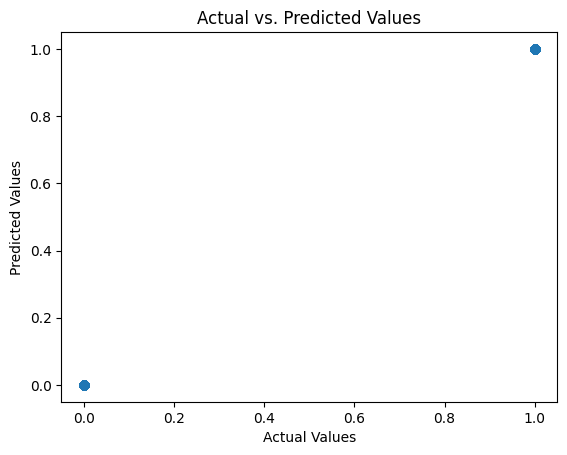

In [86]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()

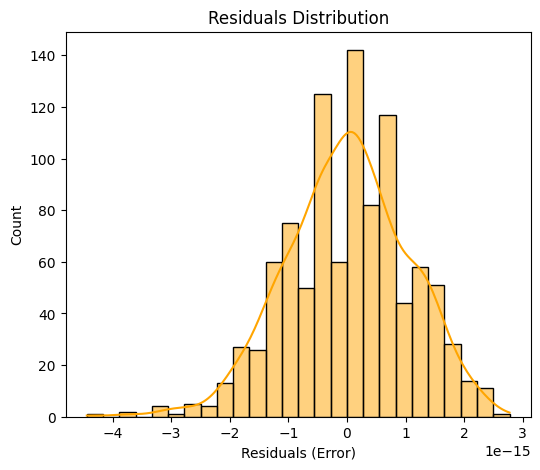

<Figure size 640x480 with 0 Axes>

In [87]:
plt.figure(figsize=(6,5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='orange')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (Error)")

plt.show()
plt.savefig("Histogram.png")

Conclusion:

In this experiment, Linear Regression algorithm
was implemented to predict the target variable
using independent variables.

Linear Regression is a supervised learning algorithm
that finds the best fit line between input and
output variables by minimizing the error.

The dataset was preprocessed by handling missing
values (NaN) using SimpleImputer with mean strategy.

The model was trained on 80% of the data and
tested on 20% of the data.

The model performance was evaluated using:
- R2 Score: _1.000
- Mean Squared Error (MSE): _0.00
- Mean Absolute Error (MAE): _0.00

Thus, Linear Regression successfully predicted
the target variable with reasonable accuracy